## Ring packing example

This notebook is very minimal and simply shows a practical example of packing differently sized
ring circuits (linear closed topology) onto the Q50 topology.

In [1]:
import iqm.qiskit_iqm as iqm
import matplotlib.pyplot as plt
from qc_parallelizer import Parallelizer, packers
import qiskit

In [2]:
backend = iqm.IQMFakeAphrodite()
print(f"Backend has {backend.num_qubits} qubits.")

Backend has 54 qubits.


In [3]:
par_backend = Parallelizer(packers.vf2.Minimizing(max_candidates=8)) \
    .across(backend, auto_exec=False)

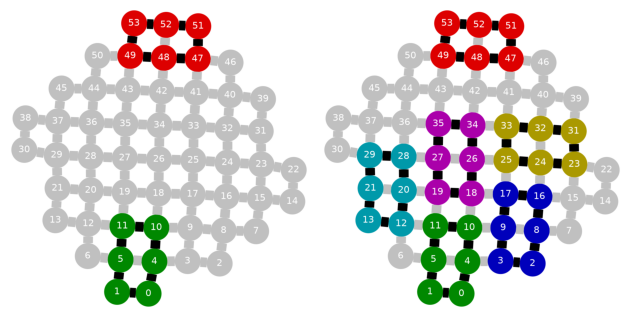

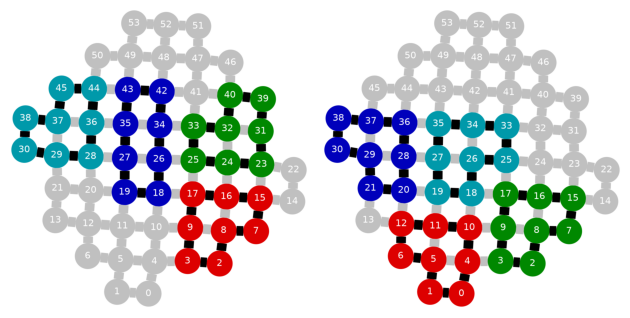

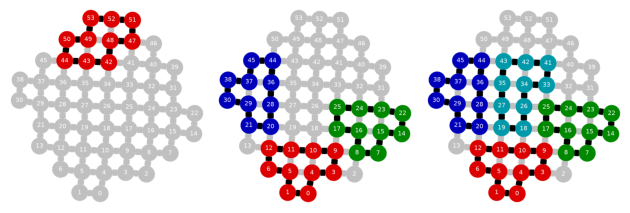

In [4]:
def generate_ring(length: int):
    qc = qiskit.QuantumCircuit(length)
    qc.h(0)
    if length > 1:
        for i in range(length):
            qc.cx(i, (i + 1) % length)
    return qc

for ring_length in [6, 8, 10]:
    circuits = [generate_ring(ring_length) for _ in range(8)]
    display(par_backend.run(circuits).draw())